In [ ]:
import geopandas as gpd
import rasterio

img = r"C:\Users\13519\data\train\vegetation\rasters\2304379_17tlh360220_17tlh360220.tif"
vec = r"C:\Users\13519\data\train\vegetation\vectors\2304379_17tlh360220_17tlh360220.geojson"

with rasterio.open(img) as src:
    print("Raster CRS:", src.crs)
    print("Raster Size:", src.width, src.height)
    print("Raster Bands:", src.count)
    print("Resolution:", src.res)

gdf = gpd.read_file(vec)

print("\nVector CRS:", gdf.crs)
print("Features:", len(gdf))
print("Geometry Types:")
print(gdf.geom_type.value_counts())

print("\nColumns:")
print(gdf.columns)

In [2]:
import geopandas as gpd
import rasterio

img = r"C:\Users\13519\data\train\vegetation\rasters\2304379_17tlh360220_17tlh360220.tif"
vec = r"C:\Users\13519\data\train\vegetation\vectors\2304379_17tlh360220_17tlh360220.geojson"

with rasterio.open(img) as src:
    print("Raster CRS:", src.crs)
    print("Raster Size:", src.width, src.height)
    print("Raster Bands:", src.count)
    print("Resolution:", src.res)

gdf = gpd.read_file(vec)

print("\nVector CRS:", gdf.crs)
print("Features:", len(gdf))
print("Geometry Types:")
print(gdf.geom_type.value_counts())

print("\nColumns:")
print(gdf.columns)

Raster CRS: PROJCS["NAD83 / UTM zone 17N",GEOGCS["NAD83",DATUM["North American Datum 1983",SPHEROID["GRS 1980",6378137,298.257222101004]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-81],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
Raster Size: 5000 5000
Raster Bands: 3
Resolution: (0.3, 0.3)


c:\Users\13519\AppData\Local\anaconda3\envs\lulc\Lib\site-packages\pyogrio\core.py:36: RuntimeWarning: Could not detect PROJ data files.  Set PROJ_LIB environment variable to the correct path.
  _init_proj_data()



Vector CRS: None
Features: 1932
Geometry Types:
Polygon    1932
Name: count, dtype: int64

Columns:
Index(['class', 'geometry'], dtype='str')


In [3]:
print(gdf["class"].value_counts())


class
Vegetation    1932
Name: count, dtype: int64


In [4]:
import geopandas as gpd

gdf = gpd.read_file(
    r"C:\Users\13519\data\train\vegetation\vectors\2304379_17tlh360220_17tlh360220.geojson"
)

print(gdf["class"].value_counts())

class
Vegetation    1932
Name: count, dtype: int64


In [6]:
import geopandas as gpd
import rasterio

img = rasterio.open(
    r"C:\Users\13519\data\train\vegetation\rasters\2304379_17tlh360220_17tlh360220.tif"
)

gdf = gpd.read_file(
    r"C:\Users\13519\data\train\vegetation\vectors\2304379_17tlh360220_17tlh360220.geojson"
)

print("Raster bounds:")
print(img.bounds)

print("\nVector bounds:")
print(gdf.total_bounds)

Raster bounds:
BoundingBox(left=336000.0, bottom=4722000.0, right=337500.0, top=4723500.0)

Vector bounds:
[ 335999.99999993 4721999.98023686  337499.62687971 4723500.00726713]


In [7]:
gdf = gdf.set_crs(img.crs)

In [8]:
from pathlib import Path

import geopandas as gpd
import numpy as np
import rasterio
from rasterio.features import rasterize

# ------------------------------------------------------------------
# Paths
# ------------------------------------------------------------------

RASTER_DIR = Path(r"C:\Users\13519\data\train\vegetation\rasters")
VECTOR_DIR = Path(r"C:\Users\13519\data\train\vegetation\vectors")
MASK_DIR = Path(r"C:\Users\13519\data\train\vegetation\masks")

MASK_DIR.mkdir(exist_ok=True)

# ------------------------------------------------------------------
# Generate masks
# ------------------------------------------------------------------

raster_files = sorted(RASTER_DIR.glob("*.tif"))

print(f"Found {len(raster_files)} raster files")

for raster_file in raster_files:

    geojson_file = VECTOR_DIR / f"{raster_file.stem}.geojson"

    if not geojson_file.exists():
        print(f"Missing vector: {geojson_file.name}")
        continue

    print(f"Processing: {raster_file.name}")

    with rasterio.open(raster_file) as src:

        # Read vegetation polygons
        gdf = gpd.read_file(geojson_file)

        # GeoJSON has no CRS, assign raster CRS
        if gdf.crs is None:
            gdf = gdf.set_crs(src.crs)

        # Rasterize vegetation polygons
        mask = rasterize(
            [(geom, 1) for geom in gdf.geometry if geom is not None],
            out_shape=(src.height, src.width),
            transform=src.transform,
            fill=0,
            all_touched=False,
            dtype=np.uint8
        )

        profile = src.profile.copy()

        profile.update(
            driver="GTiff",
            dtype=rasterio.uint8,
            count=1,
            nodata=0,
            compress="lzw"
        )

        out_mask = MASK_DIR / f"{raster_file.stem}_mask.tif"

        with rasterio.open(out_mask, "w", **profile) as dst:
            dst.write(mask, 1)

print("Done.")

Found 62 raster files
Processing: 2304379_17tlh360220_17tlh360220.tif
Processing: 2304382_17tlh360265_17tlh360265.tif
Processing: 2304410_17tlh375250_17tlh375250.tif
Processing: 2304413_17tlh375295_17tlh375295.tif
Processing: 2304439_17tlh390235_17tlh390235.tif
Processing: 2304440_17tlh390250_17tlh390250.tif
Processing: 2304441_17tlh390265_17tlh390265.tif
Processing: 2304442_17tlh390280_17tlh390280.tif
Processing: 2304443_17tlh390295_17tlh390295.tif
Processing: 2304504_17tlh420250_17tlh420250.tif
Processing: 2304505_17tlh420265_17tlh420265.tif
Processing: 2518543_17tlh405235_17tlh405235.tif
Processing: 2518548_17tlh450220_17tlh450220.tif
Processing: 2518549_17tlh450235_17tlh450235.tif
Processing: 2519007_17tlh315325_17tlh315325.tif
Processing: 2519014_17tlh345295_17tlh345295.tif
Processing: 2519015_17tlh345310_17tlh345310.tif
Processing: 2519028_17tlh375250_17tlh375250.tif
Processing: 2519029_17tlh375280_17tlh375280.tif
Processing: 2519030_17tlh375295_17tlh375295.tif
Processing: 251903

In [10]:
import rasterio
import numpy as np

mask_file = r"C:\Users\13519\data\train\vegetation\masks\2304379_17tlh360220_17tlh360220_mask.tif"

with rasterio.open(mask_file) as src:
    mask = src.read(1)

print("Shape:", mask.shape)
print("Unique values:", np.unique(mask))


Shape: (5000, 5000)
Unique values: [0 1]


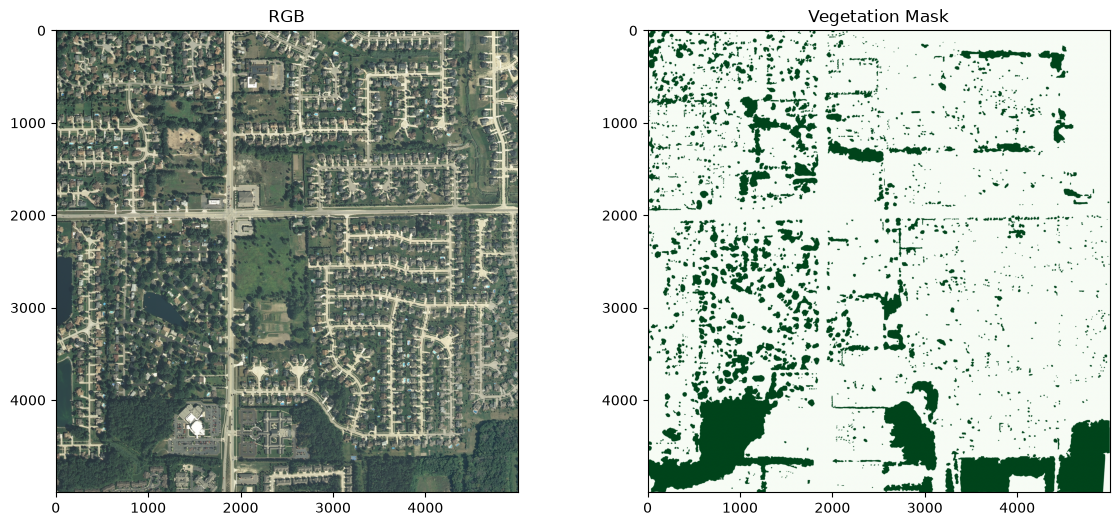

In [11]:
import matplotlib.pyplot as plt
import rasterio

img_file = r"C:\Users\13519\data\train\vegetation\rasters\2304379_17tlh360220_17tlh360220.tif"
mask_file = r"C:\Users\13519\data\train\vegetation\masks\2304379_17tlh360220_17tlh360220_mask.tif"

with rasterio.open(img_file) as src:
    img = src.read([1, 2, 3]).transpose(1, 2, 0)

with rasterio.open(mask_file) as src:
    mask = src.read(1)

plt.figure(figsize=(14,6))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("RGB")

plt.subplot(1,2,2)
plt.imshow(mask, cmap="Greens")
plt.title("Vegetation Mask")

plt.show()

In [32]:
from pathlib import Path
import rasterio
from rasterio.windows import Window
import numpy as np

# -------------------------------------------------
# Paths
# -------------------------------------------------

IMAGE_DIR = Path(r"C:\Users\13519\data\train\vegetation\rasters")
MASK_DIR = Path(r"C:\Users\13519\data\train\vegetation\masks")

OUT_IMG = Path(r"C:\Users\13519\data\train\vegetation\tiles\images")
OUT_MSK = Path(r"C:\Users\13519\data\train\vegetation\tiles\masks")

OUT_IMG.mkdir(parents=True, exist_ok=True)
OUT_MSK.mkdir(parents=True, exist_ok=True)

# -------------------------------------------------
# Parameters
# -------------------------------------------------

TILE_SIZE = 512
STRIDE = 256

tile_count = 0

# -------------------------------------------------
# Generate Tiles
# -------------------------------------------------

for img_path in IMAGE_DIR.glob("*.tif"):

    mask_path = MASK_DIR / f"{img_path.stem}_mask.tif"

    if not mask_path.exists():
        print(f"Missing mask: {mask_path.name}")
        continue

    print(f"Processing {img_path.name}")

    with rasterio.open(img_path) as src_img, rasterio.open(mask_path) as src_mask:

        width = src_img.width
        height = src_img.height

        for y in range(0, height - TILE_SIZE + 1, STRIDE):
            for x in range(0, width - TILE_SIZE + 1, STRIDE):

                window = Window(
                    col_off=x,
                    row_off=y,
                    width=TILE_SIZE,
                    height=TILE_SIZE
                )

                img_tile = src_img.read(
                    [1, 2, 3],
                    window=window
                )

                mask_tile = src_mask.read(
                    1,
                    window=window
                )

                # skip empty vegetation tiles
                

                tile_id = f"{img_path.stem}_{y}_{x}"

                img_profile = src_img.profile.copy()
                img_profile.update(
                    height=TILE_SIZE,
                    width=TILE_SIZE,
                    transform=rasterio.windows.transform(
                        window,
                        src_img.transform
                    )
                )

                mask_profile = src_mask.profile.copy()
                mask_profile.update(
                    height=TILE_SIZE,
                    width=TILE_SIZE,
                    transform=rasterio.windows.transform(
                        window,
                        src_mask.transform
                    )
                )

                # save image tile
                with rasterio.open(
                    OUT_IMG / f"{tile_id}.tif",
                    "w",
                    **img_profile
                ) as dst:
                    dst.write(img_tile)

                # save mask tile
                with rasterio.open(
                    OUT_MSK / f"{tile_id}.tif",
                    "w",
                    **mask_profile
                ) as dst:
                    dst.write(mask_tile, 1)

                tile_count += 1

print("\nFinished")
print("Tiles created:", tile_count)

Processing 2304379_17tlh360220_17tlh360220.tif
Processing 2304382_17tlh360265_17tlh360265.tif
Processing 2304410_17tlh375250_17tlh375250.tif
Processing 2304413_17tlh375295_17tlh375295.tif
Processing 2304439_17tlh390235_17tlh390235.tif
Processing 2304440_17tlh390250_17tlh390250.tif
Processing 2304441_17tlh390265_17tlh390265.tif
Processing 2304442_17tlh390280_17tlh390280.tif
Processing 2304443_17tlh390295_17tlh390295.tif
Processing 2304504_17tlh420250_17tlh420250.tif
Processing 2304505_17tlh420265_17tlh420265.tif
Processing 2518543_17tlh405235_17tlh405235.tif
Processing 2518548_17tlh450220_17tlh450220.tif
Processing 2518549_17tlh450235_17tlh450235.tif
Processing 2519007_17tlh315325_17tlh315325.tif
Processing 2519014_17tlh345295_17tlh345295.tif
Processing 2519015_17tlh345310_17tlh345310.tif
Processing 2519028_17tlh375250_17tlh375250.tif
Processing 2519029_17tlh375280_17tlh375280.tif
Processing 2519030_17tlh375295_17tlh375295.tif
Processing 2519031_17tlh375310_17tlh375310.tif
Processing 25

In [33]:
from pathlib import Path

img_tiles = list(
    Path(
        r"C:\Users\13519\data\train\vegetation\tiles\images"
    ).glob("*.tif")
)

mask_tiles = list(
    Path(
        r"C:\Users\13519\data\train\vegetation\tiles\masks"
    ).glob("*.tif")
)

print("Image tiles:", len(img_tiles))
print("Mask tiles :", len(mask_tiles))

Image tiles: 19228
Mask tiles : 19228


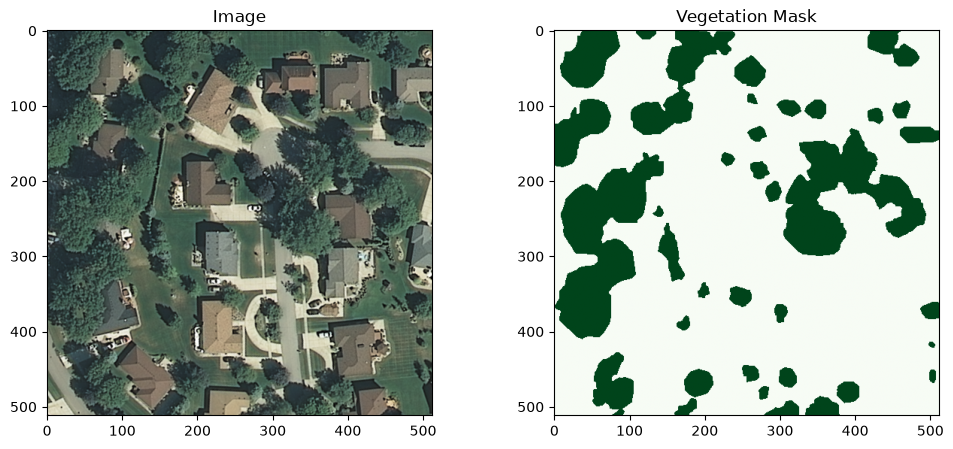

In [34]:
import matplotlib.pyplot as plt
import rasterio

img_tile = r"C:\Users\13519\data\train\vegetation\tiles\images\2304379_17tlh360220_17tlh360220_0_0.tif"
mask_tile = r"C:\Users\13519\data\train\vegetation\tiles\masks\2304379_17tlh360220_17tlh360220_0_0.tif"

with rasterio.open(img_tile) as src:
    img = src.read([1,2,3]).transpose(1,2,0)

with rasterio.open(mask_tile) as src:
    mask = src.read(1)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Image")

plt.subplot(1,2,2)
plt.imshow(mask, cmap="Greens")
plt.title("Vegetation Mask")

plt.show()

In [15]:
from pathlib import Path
import rasterio
import numpy as np

mask_dir = Path(
    r"C:\Users\13519\data\train\vegetation\tiles\masks"
)

veg_pixels = 0
bg_pixels = 0

for mask_file in mask_dir.glob("*.tif"):

    with rasterio.open(mask_file) as src:
        mask = src.read(1)

    veg_pixels += np.sum(mask == 1)
    bg_pixels += np.sum(mask == 0)

total = veg_pixels + bg_pixels

print("Vegetation %:", 100 * veg_pixels / total)
print("Background %:", 100 * bg_pixels / total)

Vegetation %: 11.429506062169489
Background %: 88.5704939378305


In [16]:
from pathlib import Path
import rasterio
import numpy as np

mask_dir = Path(
    r"C:\Users\13519\data\train\vegetation\tiles\masks"
)

coverage = []

for mask_file in mask_dir.glob("*.tif"):
    with rasterio.open(mask_file) as src:
        mask = src.read(1)

    pct = (mask == 1).mean() * 100
    coverage.append(pct)

coverage = np.array(coverage)

print("Tiles:", len(coverage))
print("Mean vegetation %:", coverage.mean())
print("Median vegetation %:", np.median(coverage))
print("Min:", coverage.min())
print("Max:", coverage.max())

print("Tiles > 1% vegetation :", np.sum(coverage > 1))
print("Tiles > 5% vegetation :", np.sum(coverage > 5))
print("Tiles > 10% vegetation:", np.sum(coverage > 10))

Tiles: 7567
Mean vegetation %: 11.429506062169489
Median vegetation %: 4.2083740234375
Min: 0.0194549560546875
Max: 100.0
Tiles > 1% vegetation : 5982
Tiles > 5% vegetation : 3417
Tiles > 10% vegetation: 2016


In [36]:
from pathlib import Path

IMG_DIR = Path(
    r"C:\Users\13519\data\train\vegetation\tiles\images"
)

scene_ids = set()

for f in IMG_DIR.glob("*.tif"):
    scene_ids.add("_".join(f.stem.split("_")[:-2]))

print("Tile scenes:", len(scene_ids))

Tile scenes: 62


In [38]:
from pathlib import Path
import random

IMG_DIR = Path(
    r"C:\Users\13519\data\train\vegetation\tiles\images"
)

scene_ids = sorted({
    "_".join(f.stem.split("_")[:-2])
    for f in IMG_DIR.glob("*.tif")
})

print("Scenes:", len(scene_ids))

random.seed(42)
random.shuffle(scene_ids)

n = len(scene_ids)

train_scenes = scene_ids[:int(0.70*n)]
val_scenes = scene_ids[int(0.70*n):int(0.85*n)]
test_scenes = scene_ids[int(0.85*n):]

Path("train_scenes.txt").write_text("\n".join(train_scenes))
Path("val_scenes.txt").write_text("\n".join(val_scenes))
Path("test_scenes.txt").write_text("\n".join(test_scenes))

print("Train:", len(train_scenes))
print("Val:", len(val_scenes))
print("Test:", len(test_scenes))

Scenes: 62
Train: 43
Val: 9
Test: 10


In [40]:
from pathlib import Path
import shutil

IMG_DIR = Path(
    r"C:\Users\13519\data\train\vegetation\tiles\images"
)

MASK_DIR = Path(
    r"C:\Users\13519\data\train\vegetation\tiles\masks"
)

OUT_BASE = Path(
    r"C:\Users\13519\data\train\vegetation\vegetation_dino"
)

for split in ["train", "val", "test"]:

    (OUT_BASE / split / "images").mkdir(
        parents=True,
        exist_ok=True
    )

    (OUT_BASE / split / "masks").mkdir(
        parents=True,
        exist_ok=True
    )

train_scenes = set(
    Path("train_scenes.txt").read_text().splitlines()
)

val_scenes = set(
    Path("val_scenes.txt").read_text().splitlines()
)

test_scenes = set(
    Path("test_scenes.txt").read_text().splitlines()
)

counts = {
    "train": 0,
    "val": 0,
    "test": 0
}

for img_file in IMG_DIR.glob("*.tif"):

    scene_id = "_".join(img_file.stem.split("_")[:-2])

    if scene_id in train_scenes:
        split = "train"

    elif scene_id in val_scenes:
        split = "val"

    else:
        split = "test"

    mask_file = MASK_DIR / img_file.name

    if not mask_file.exists():
        print("Missing:", mask_file)
        continue

    shutil.copy2(
        img_file,
        OUT_BASE / split / "images" / img_file.name
    )

    shutil.copy2(
        mask_file,
        OUT_BASE / split / "masks" / mask_file.name
    )

    counts[split] += 1

print(counts)

{'train': 13336, 'val': 2652, 'test': 3240}


In [41]:
from pathlib import Path

BASE = Path(
    r"C:\Users\13519\data\train\vegetation\vegetation_dino"
)

for split in ["train", "val", "test"]:
    imgs = len(list((BASE / split / "images").glob("*.tif")))
    masks = len(list((BASE / split / "masks").glob("*.tif")))

    print(split, imgs, masks)

train 13336 13336
val 2652 2652
test 3240 3240


In [42]:
from pathlib import Path
import rasterio
import numpy as np

mask_file = next(
    Path(
        r"C:\Users\13519\data\train\vegetation\vegetation_dino\train\masks"
    ).glob("*.tif")
)

with rasterio.open(mask_file) as src:
    mask = src.read(1)

print(np.unique(mask))

[0 1]


In [43]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

False
CPU


In [48]:
import torch

ckpt = torch.load(
    r"C:\Users\13519\first_version_change_detection\dinov3_vits16_pretrain_lvd1689m-08c60483.pth",
    map_location="cpu"
)

print(type(ckpt))

if isinstance(ckpt, dict):
    print("\nKeys:")
    print(list(ckpt.keys())[:20])


<class 'collections.OrderedDict'>

Keys:
['cls_token', 'storage_tokens', 'mask_token', 'patch_embed.proj.weight', 'patch_embed.proj.bias', 'rope_embed.periods', 'blocks.0.norm1.weight', 'blocks.0.norm1.bias', 'blocks.0.attn.qkv.weight', 'blocks.0.attn.qkv.bias', 'blocks.0.attn.qkv.bias_mask', 'blocks.0.attn.proj.weight', 'blocks.0.attn.proj.bias', 'blocks.0.ls1.gamma', 'blocks.0.norm2.weight', 'blocks.0.norm2.bias', 'blocks.0.mlp.fc1.weight', 'blocks.0.mlp.fc1.bias', 'blocks.0.mlp.fc2.weight', 'blocks.0.mlp.fc2.bias']


In [49]:
import torch

ckpt = torch.load(
    r"C:\Users\13519\first_version_change_detection\dinov3_vits16_pretrain_lvd1689m-08c60483.pth",
    map_location="cpu"
)

if isinstance(ckpt, dict):

    if "model" in ckpt:
        state_dict = ckpt["model"]

    elif "state_dict" in ckpt:
        state_dict = ckpt["state_dict"]

    else:
        state_dict = ckpt

else:
    state_dict = ckpt

print("Parameters:", len(state_dict))

for i, k in enumerate(state_dict.keys()):
    print(k)

    if i > 20:
        break

Parameters: 188
cls_token
storage_tokens
mask_token
patch_embed.proj.weight
patch_embed.proj.bias
rope_embed.periods
blocks.0.norm1.weight
blocks.0.norm1.bias
blocks.0.attn.qkv.weight
blocks.0.attn.qkv.bias
blocks.0.attn.qkv.bias_mask
blocks.0.attn.proj.weight
blocks.0.attn.proj.bias
blocks.0.ls1.gamma
blocks.0.norm2.weight
blocks.0.norm2.bias
blocks.0.mlp.fc1.weight
blocks.0.mlp.fc1.bias
blocks.0.mlp.fc2.weight
blocks.0.mlp.fc2.bias
blocks.0.ls2.gamma
blocks.1.norm1.weight


In [51]:
import torch

ckpt = torch.load(
    r"C:\Users\13519\first_version_change_detection\dinov3_vits16_pretrain_lvd1689m-08c60483.pth",
    map_location="cpu"
)

print("cls_token:", ckpt["cls_token"].shape)
print("patch_embed:", ckpt["patch_embed.proj.weight"].shape)


cls_token: torch.Size([1, 1, 384])
patch_embed: torch.Size([384, 3, 16, 16])


In [52]:
for k in ckpt.keys():
    pass

print("Last key:", k)


Last key: norm.bias


In [53]:
for k in list(ckpt.keys())[-20:]:
    print(k)


blocks.10.mlp.fc2.weight
blocks.10.mlp.fc2.bias
blocks.10.ls2.gamma
blocks.11.norm1.weight
blocks.11.norm1.bias
blocks.11.attn.qkv.weight
blocks.11.attn.qkv.bias
blocks.11.attn.qkv.bias_mask
blocks.11.attn.proj.weight
blocks.11.attn.proj.bias
blocks.11.ls1.gamma
blocks.11.norm2.weight
blocks.11.norm2.bias
blocks.11.mlp.fc1.weight
blocks.11.mlp.fc1.bias
blocks.11.mlp.fc2.weight
blocks.11.mlp.fc2.bias
blocks.11.ls2.gamma
norm.weight
norm.bias


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import timm


class DinoV3Vegetation(nn.Module):

    def __init__(self, ckpt_path):
        super().__init__()

        self.encoder = timm.create_model(
            "vit_small_patch16_224",
            pretrained=False,
            num_classes=0,
            img_size=512
        )

        ckpt = torch.load(
            ckpt_path,
            map_location="cpu"
        )

        self.encoder.load_state_dict(
            ckpt,
            strict=False
        )

        self.decoder = nn.Sequential(
            nn.Conv2d(384, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            nn.Conv2d(256, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.Conv2d(64, 1, 1)
        )

    def forward(self, x):

        B, C, H, W = x.shape

        feat = self.encoder.forward_features(x)

        if feat.ndim == 3:
            feat = feat[:, 1:, :]

        h = H // 16
        w = W // 16

        feat = feat.transpose(1, 2)

        feat = feat.reshape(
            B,
            384,
            h,
            w
        )

        logits = self.decoder(feat)

        logits = F.interpolate(
            logits,
            size=(H, W),
            mode="bilinear",
            align_corners=False
        )

        return logits

c:\Users\13519\AppData\Local\anaconda3\envs\lulc\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
model = DinoV3Vegetation(
    r"C:\Users\13519\first_version_change_detection\dinov3_vits16_pretrain_lvd1689m-08c60483.pth"
)

x = torch.randn(1, 3, 512, 512)

with torch.no_grad():
    y = model(x)

print(y.shape)

torch.Size([1, 1, 512, 512])


In [3]:
import torch

bce = torch.nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([3.0])
)


def dice_loss(pred, target):

    pred = torch.sigmoid(pred)

    smooth = 1e-6

    intersection = (pred * target).sum()

    union = pred.sum() + target.sum()

    dice = (
        2 * intersection + smooth
    ) / (
        union + smooth
    )

    return 1 - dice

In [4]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4
)

In [5]:
from pathlib import Path
import rasterio
import torch
import numpy as np
from torch.utils.data import Dataset


class VegetationDataset(Dataset):

    def __init__(self, root):

        self.img_dir = Path(root) / "images"
        self.mask_dir = Path(root) / "masks"

        self.images = sorted(
            self.img_dir.glob("*.tif")
        )

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        img_path = self.images[idx]
        mask_path = self.mask_dir / img_path.name

        with rasterio.open(img_path) as src:
            image = src.read([1, 2, 3]).astype(np.float32)

        image /= 255.0

        with rasterio.open(mask_path) as src:
            mask = src.read(1).astype(np.float32)

        image = torch.tensor(
            image,
            dtype=torch.float32
        )

        mask = torch.tensor(
            mask,
            dtype=torch.float32
        ).unsqueeze(0)

        return image, mask

In [6]:
train_ds = VegetationDataset(
    r"C:\Users\13519\data\train\vegetation\vegetation_dino\train"
)

val_ds = VegetationDataset(
    r"C:\Users\13519\data\train\vegetation\vegetation_dino\val"
)

test_ds = VegetationDataset(
    r"C:\Users\13519\data\train\vegetation\vegetation_dino\test"
)

In [7]:
print(len(train_ds))
print(len(val_ds))
print(len(test_ds))

13336
2652
3240


In [8]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_ds,
    batch_size=1,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_ds,
    batch_size=1,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_ds,
    batch_size=1,
    shuffle=False,
    num_workers=0
)

In [9]:
import random

for _ in range(20):

    idx = random.randint(0, len(train_ds)-1)

    _, mask = train_ds[idx]

    vals = mask.unique()

    print(idx, vals.tolist())

9168 [0.0]
10161 [0.0, 1.0]
4638 [0.0]
12757 [0.0, 1.0]
3888 [0.0]
6131 [0.0]
9576 [0.0]
11191 [0.0, 1.0]
11702 [0.0, 1.0]
11265 [0.0, 1.0]
7343 [0.0, 1.0]
11269 [0.0, 1.0]
10841 [0.0, 1.0]
9954 [0.0]
3042 [0.0, 1.0]
3795 [0.0]
10494 [0.0, 1.0]
5910 [0.0]
2497 [0.0]
9737 [0.0]


In [10]:
for p in model.encoder.parameters():
    p.requires_grad = False

In [11]:
trainable = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

total = sum(
    p.numel()
    for p in model.parameters()
)

print(f"Trainable: {trainable:,}")
print(f"Total: {total:,}")

Trainable: 1,033,217
Total: 23,016,833


In [12]:
import time

start = time.time()

images, masks = next(iter(train_loader))

print("Loaded batch in:", time.time() - start, "seconds")
print(images.shape)
print(masks.shape)

Loaded batch in: 0.22983527183532715 seconds
torch.Size([1, 3, 512, 512])
torch.Size([1, 1, 512, 512])


In [23]:
from torch.utils.data import Subset, DataLoader
import torch

# =====================================
# Freeze DINO Encoder
# =====================================

for p in model.encoder.parameters():
    p.requires_grad = False

# =====================================
# Subset
# =====================================

train_subset = Subset(
    train_ds,
    range(500)
)

train_loader = DataLoader(
    train_subset,
    batch_size=4,
    shuffle=True,
    num_workers=0
)

# =====================================
# Device
# =====================================

device = "cpu"

model = model.to(device)

# =====================================
# Optimizer
# =====================================

optimizer = torch.optim.AdamW(
    model.decoder.parameters(),
    lr=1e-3
)

# =====================================
# Losses
# =====================================

bce = torch.nn.BCEWithLogitsLoss()

def dice_loss(pred, target):

    pred = torch.sigmoid(pred)

    smooth = 1e-6

    intersection = (pred * target).sum()

    union = pred.sum() + target.sum()

    dice = (
        2 * intersection + smooth
    ) / (
        union + smooth
    )

    return 1 - dice

# =====================================
# Training
# =====================================

EPOCHS = 5

best_loss = float("inf")

for epoch in range(EPOCHS):

    model.train()

    running_loss = 0.0

    for batch_idx, (images, masks) in enumerate(train_loader):

        images = images.to(device)
        masks = masks.to(device)

        preds = model(images)

        loss_bce = bce(preds, masks)

        loss_dice = dice_loss(
            preds,
            masks
        )

        loss = (
            0.5 * loss_bce +
            0.5 * loss_dice
        )

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        if batch_idx % 10 == 0:

            print(
                f"Epoch {epoch+1}/{EPOCHS} | "
                f"Batch {batch_idx}/{len(train_loader)} | "
                f"Loss {loss.item():.4f}"
            )

    epoch_loss = (
        running_loss /
        len(train_loader)
    )

    print(
        "\n"
        + "=" * 50
    )

    print(
        f"Epoch {epoch+1}/{EPOCHS} "
        f"Average Loss = {epoch_loss:.4f}"
    )

    print(
        "=" * 50
    )

    torch.save(
        model.state_dict(),
        f"vegetation_epoch_{epoch+1}.pth"
    )

    if epoch_loss < best_loss:

        best_loss = epoch_loss

        torch.save(
            model.state_dict(),
            "vegetation_dinov3_best.pth"
        )

        print(
            "✅ Saved Best Model\n"
        )

Epoch 1/5 | Batch 0/125 | Loss 0.7709
Epoch 1/5 | Batch 10/125 | Loss 0.6918
Epoch 1/5 | Batch 20/125 | Loss 0.6200
Epoch 1/5 | Batch 30/125 | Loss 0.6510
Epoch 1/5 | Batch 40/125 | Loss 0.6531
Epoch 1/5 | Batch 50/125 | Loss 0.6133
Epoch 1/5 | Batch 60/125 | Loss 0.5459
Epoch 1/5 | Batch 70/125 | Loss 0.6109
Epoch 1/5 | Batch 80/125 | Loss 0.5842
Epoch 1/5 | Batch 90/125 | Loss 0.6470
Epoch 1/5 | Batch 100/125 | Loss 0.5529
Epoch 1/5 | Batch 110/125 | Loss 0.5988
Epoch 1/5 | Batch 120/125 | Loss 0.5672

Epoch 1/5 Average Loss = 0.6124
✅ Saved Best Model

Epoch 2/5 | Batch 0/125 | Loss 0.5505
Epoch 2/5 | Batch 10/125 | Loss 0.6036
Epoch 2/5 | Batch 20/125 | Loss 0.6017
Epoch 2/5 | Batch 30/125 | Loss 0.5634
Epoch 2/5 | Batch 40/125 | Loss 0.4983
Epoch 2/5 | Batch 50/125 | Loss 0.3953
Epoch 2/5 | Batch 60/125 | Loss 0.6343
Epoch 2/5 | Batch 70/125 | Loss 0.5592
Epoch 2/5 | Batch 80/125 | Loss 0.6125
Epoch 2/5 | Batch 90/125 | Loss 0.5203
Epoch 2/5 | Batch 100/125 | Loss 0.6110
Epoch 2/5

In [13]:
model.eval()

image, mask = train_ds[0]

with torch.no_grad():

    pred = model(
        image.unsqueeze(0)
    )

pred = torch.sigmoid(pred)

print(
    pred.min().item(),
    pred.max().item()
)

0.19072747230529785 0.9828306436538696


In [12]:
import torch

model = DinoV3Vegetation(
    r"C:\Users\13519\first_version_change_detection\dinov3_vits16_pretrain_lvd1689m-08c60483.pth"
)

model.load_state_dict(
    torch.load(
        r"C:\Users\13519\first_version_change_detection\vegetation_dinov3_best.pth",
        map_location="cpu"
    )
)

model.eval()

print("Model loaded successfully")
train_ds = VegetationDataset(
    r"C:\Users\13519\data\train\vegetation\vegetation_dino\train"
)

Model loaded successfully


In [14]:
image, mask = train_ds[0]

with torch.no_grad():
    pred = model(image.unsqueeze(0))

print(pred.shape)

torch.Size([1, 1, 512, 512])


In [15]:
print(type(model))
print(len(train_ds))

<class '__main__.DinoV3Vegetation'>
13336


In [16]:
import matplotlib.pyplot as plt
import torch

image, mask = train_ds[0]

print(image.shape)
print(mask.shape)

with torch.no_grad():
    pred = model(image.unsqueeze(0))

pred = torch.sigmoid(pred)

print(pred.shape)


torch.Size([3, 512, 512])
torch.Size([1, 512, 512])
torch.Size([1, 1, 512, 512])


In [17]:
import matplotlib

matplotlib.use("Agg")

import matplotlib.pyplot as plt

In [19]:
from PIL import Image
import numpy as np

# Image
img = image.permute(1,2,0).numpy()
img = (img * 255).clip(0,255).astype(np.uint8)

Image.fromarray(img).save(
    r"C:\Users\13519\first_version_change_detection\image.png"
)

# Ground Truth
gt = mask.squeeze().numpy()
gt = (gt * 255).astype(np.uint8)

Image.fromarray(gt).save(
    r"C:\Users\13519\first_version_change_detection\groundtruth.png"
)

# Prediction
pred_np = pred.squeeze().cpu().numpy()
pred_np = (pred_np * 255).astype(np.uint8)

Image.fromarray(pred_np).save(
    r"C:\Users\13519\first_version_change_detection\prediction.png"
)

print("Saved all images")


Saved all images


In [ ]:
from torch.utils.data import Subset, DataLoader
import torch

# =====================================
# Freeze DINO Encoder
# =====================================

for p in model.encoder.parameters():
    p.requires_grad = True

# =====================================
# Subset
# =====================================

train_subset = Subset(
    train_ds,
    range(5000)
)

train_loader = DataLoader(
    train_subset,
    batch_size=8,
    shuffle=True,
    num_workers=0
)

# =====================================
# Device
# =====================================

device = "cpu"

model = model.to(device)

# =====================================
# Optimizer
# =====================================

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-5
)


# =====================================
# Losses
# =====================================

bce = torch.nn.BCEWithLogitsLoss()

def dice_loss(pred, target):

    pred = torch.sigmoid(pred)

    smooth = 1e-6

    intersection = (pred * target).sum()

    union = pred.sum() + target.sum()

    dice = (
        2 * intersection + smooth
    ) / (
        union + smooth
    )

    return 1 - dice

# =====================================
# Training
# =====================================

EPOCHS = 100

best_loss = float("inf")

for epoch in range(EPOCHS):

    model.train()

    running_loss = 0.0

    for batch_idx, (images, masks) in enumerate(train_loader):

        images = images.to(device)
        masks = masks.to(device)

        preds = model(images)

        loss_bce = bce(preds, masks)

        loss_dice = dice_loss(
            preds,
            masks
        )

        loss = (
            0.5 * loss_bce +
            0.5 * loss_dice
        )

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        if batch_idx % 10 == 0:

            print(
                f"Epoch {epoch+1}/{EPOCHS} | "
                f"Batch {batch_idx}/{len(train_loader)} | "
                f"Loss {loss.item():.4f}"
            )

    epoch_loss = (
        running_loss /
        len(train_loader)
    )

    print(
        "\n"
        + "=" * 50
    )

    print(
        f"Epoch {epoch+1}/{EPOCHS} "
        f"Average Loss = {epoch_loss:.4f}"
    )

    print(
        "=" * 50
    )

    torch.save(
        model.state_dict(),
        f"vegetation_epoch_{epoch+1}.pth"
    )

    if epoch_loss < best_loss:

        best_loss = epoch_loss

        torch.save(
            model.state_dict(),
            "vegetation_dinov3_best.pth"
        )

        print(
            "✅ Saved Best Model\n"
        )

Epoch 1/100 | Batch 0/625 | Loss 0.5607
